# 3.1. Linear Regression

Let's skip the theory and go straight to the interactive code examples. But before that, let's make sure the MindSpore 2.8.0 machine learning framework and dependent libraries for CANN 8.5.0 are installed.

In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Let's initialize MindSpore to use the Ascend NPU chip on our OrangePi AIpro \(20T\) development board and confirm that MindSpore is correctly installed. There's only 1 NPU processor and core on the OrangePi AIpro \(20T\) based on Ascend 310B series processors so let's set the device ID to 0.

In [2]:
import mindspore
mindspore.set_device(device_target='Ascend', device_id=0)
mindspore.run_check()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


It's normal to see `SyntaxWarning` and `UserWarning` messages unless you see `[ERROR]` or `[CRITICAL]` messages as well. In case you encounter the latter, seek the [Ascend](https://www.hiascend.com/) forum for help.

Seeing the output below means that MindSpore is installed correctly and ready to use.

```text
MindSpore version: 2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!
```

## 3.1.2. Vectorization for Speed

MindSpore tensors allow us to accelerate vector-vector, matrix-vector, matrix-matrix and general tensor computational operations by delegating these simple yet repetitive computational operations to specialized hardware known as neural processing units or NPUs. NPUs allow us to perform these low-level computational operations automatically and in parallel instead of writing nested Python `for` loops. This makes our code more efficient, portable and less error-prone. 

An example below of adding two vectors element-wise using a Python `for` loop, versus leveraging the NPU's capabilities to perform these computations directly and in parallel. Notice the huge performance difference especially when `n` becomes large.

In [3]:
import mindspore.ops as ops

n = 10000
a = ops.ones(n)
b = ops.ones(n)
a, b

(Tensor(shape=[10000], dtype=Float32, value= [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00 ...  1.00000000e+00,  1.00000000e+00,  1.00000000e+00]),
 Tensor(shape=[10000], dtype=Float32, value= [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00 ...  1.00000000e+00,  1.00000000e+00,  1.00000000e+00]))

In [4]:
import time

start_time = time.perf_counter()
c = ops.zeros(n)
for i in range(n):
    c[i] = a[i] + b[i]
elapsed_time = time.perf_counter() - start_time
c, elapsed_time

(Tensor(shape=[10000], dtype=Float32, value= [ 2.00000000e+00,  2.00000000e+00,  2.00000000e+00 ...  2.00000000e+00,  2.00000000e+00,  2.00000000e+00]),
 7.841663438999603)

In [5]:
start_time = time.perf_counter()
d = a + b
elapsed_time = time.perf_counter() - start_time
ops.all(c == d).item(), elapsed_time

(True, 0.003189099999872269)

## 3.1.3. The Normal Distribution and Squared Loss

A normal distribution, otherwise known as a Gaussian distribution, is a probability density function characterized by the formula below.

$$
\begin{align}
p(x) &= \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{1}{2\sigma^2}(x-\mu)^2}
\end{align}
$$

$\mu$ is the mean of the normal distribution and $\sigma^2$ is the variance. We use the notation $X \sim N(\mu,\sigma^2)$ to signify that the probability distribution of random variable $X$ follows a normal distribution. 

In the special case where $\mu = 0$ and $\sigma^2 = 1$, we say the random variable $X$ follows the standard normal distribution: $X \sim N(0, 1)$. The standard normal distribution is given by the formula below obtained by substituting $\mu = 0$ and $\sigma^2 = 1$ into the above formula.

$$
\begin{align}
p(x) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}x^2}
\end{align}
$$

Relative to the standard normal distribution curve:

1. A normal distribution $N(\mu,0)$ is essentially the standard normal distribution translated $\mu$ units horizontally
1. A normal distribution $N(0,\sigma^2)$ is essentially the standard normal distribution stretched horizontally by a factor of $\sigma$
1. A normal distribution $N(\mu,\sigma^2)$ is essentially the standard normal distribution stretched horizontally by a factor of $\sigma$, then translated $\mu$ units horizontally

The shape of a normal distribution resembles that of a bell and is therefore also known as a "bell curve". Let's define the normal distribution from first principles and plot a few examples of this "bell curve" with Matplotlib to visualize and understand it. But first, we have to install Matplotlib.

In [6]:
%pip install matplotlib==3.10.8


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import math

def normal(x, mu, sigma):
    return 1 / math.sqrt(2 * math.pi * sigma ** 2) * ops.exp(-1 / (2 * sigma ** 2) * (x - mu) ** 2)

/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/c

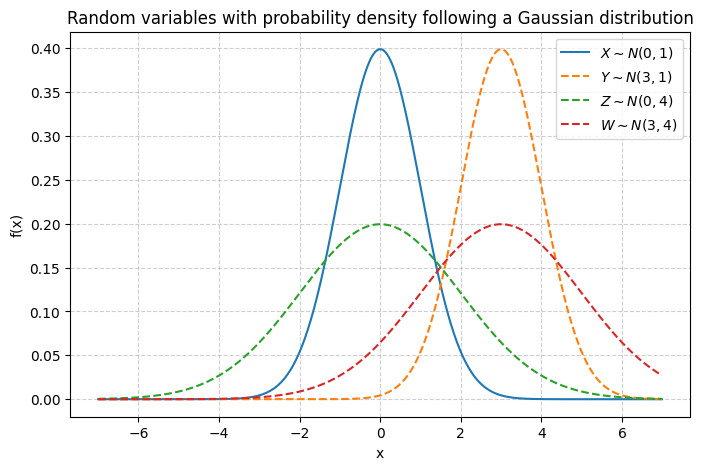

In [8]:
import matplotlib.pyplot as plt

x = ops.arange(-7, 7, 0.01)
X = normal(x, 0, 1)
Y = normal(x, 3, 1)
Z = normal(x, 0, 2)
W = normal(x, 3, 2)

x_np = x.asnumpy()
X_np = X.asnumpy()
Y_np = Y.asnumpy()
Z_np = Z.asnumpy()
W_np = W.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(x_np, X_np, label=r'$X \sim N(0, 1)$', linestyle='-')
plt.plot(x_np, Y_np, label=r'$Y \sim N(3, 1)$', linestyle='--')
plt.plot(x_np, Z_np, label=r'$Z \sim N(0, 4)$', linestyle='--')
plt.plot(x_np, W_np, label=r'$W \sim N(3, 4)$', linestyle='--')

plt.title('Random variables with probability density following a Gaussian distribution')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

Assuming a linear regression model with additive Gaussian noise, we wish to find parameters $\mathbf{w}$, $b$ maximizing the likelihood of the entire dataset. By reframing our objective to minimize the negative log-likelihood of the entire dataset, we find that removing the constant term in the resulting formula yields a term proportional to the expression $\frac{1}{n} \sum_{i=1}^{n} \frac{1}{2} (\hat{y_i} - y_i)^2$. This expression is known as the mean squared error, often abbreviated as MSE.

Since in machine learning we want to find parameters for our model which minimizes the value of some loss function, we can set the MSE as our loss function for linear regression problems with additive Gaussian noise.